## Importing libraries for data handling, visualization, and modeling

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay



## Loading dataset

In [2]:
# Loading the Telco Customer Churn dataset
df = pd.read_csv("data/telco_customer_churn.csv")

In [3]:
# dataset overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Exploratory Data Analysis (EDA)

In [5]:
# Convert 'TotalCharges' to numeric (coerce errors) and fill missing values with median
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
# Identify categorical columns
categorical_cols = df.select_dtypes(exclude = [np.number]).columns
categorical_cols

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

In [8]:
for col in categorical_cols:
  print(col)
  print(df[col].unique())

customerID
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
gender
['Female' 'Male']
Partner
['Yes' 'No']
Dependents
['No' 'Yes']
PhoneService
['No' 'Yes']
MultipleLines
['No phone service' 'No' 'Yes']
InternetService
['DSL' 'Fiber optic' 'No']
OnlineSecurity
['No' 'Yes' 'No internet service']
OnlineBackup
['Yes' 'No' 'No internet service']
DeviceProtection
['No' 'Yes' 'No internet service']
TechSupport
['No' 'Yes' 'No internet service']
StreamingTV
['No' 'Yes' 'No internet service']
StreamingMovies
['No' 'Yes' 'No internet service']
Contract
['Month-to-month' 'One year' 'Two year']
PaperlessBilling
['Yes' 'No']
PaymentMethod
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn
['No' 'Yes']


<Axes: xlabel='Churn', ylabel='count'>

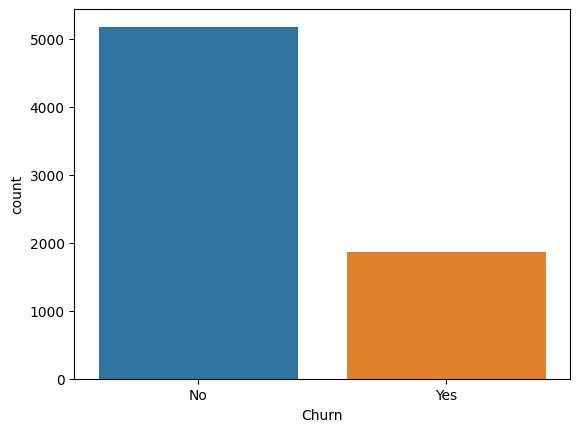

In [9]:
# Distribution of target variable
sns.countplot(df, x= 'Churn', hue= 'Churn')

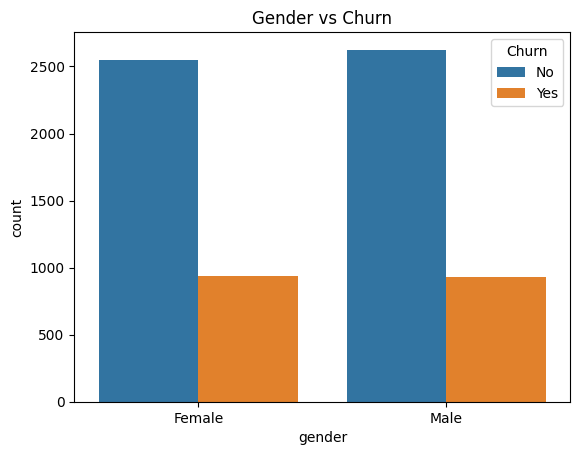

In [10]:
sns.countplot(data=df, x='gender', hue='Churn')
plt.title('Gender vs Churn')
plt.show()


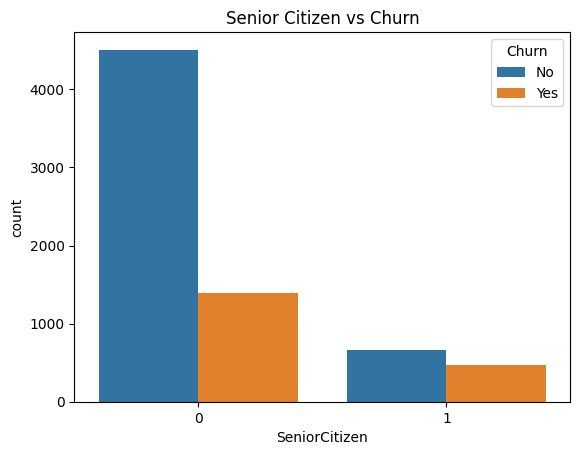

In [11]:
sns.countplot(data=df, x='SeniorCitizen', hue='Churn')
plt.title('Senior Citizen vs Churn')
plt.show()

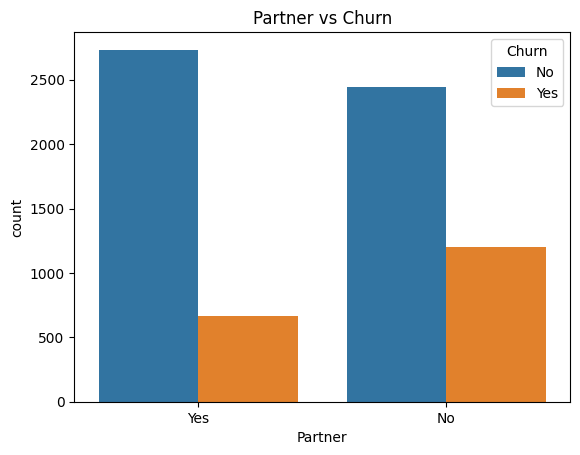

In [12]:
sns.countplot(data=df, x='Partner', hue='Churn')
plt.title('Partner vs Churn')
plt.show()

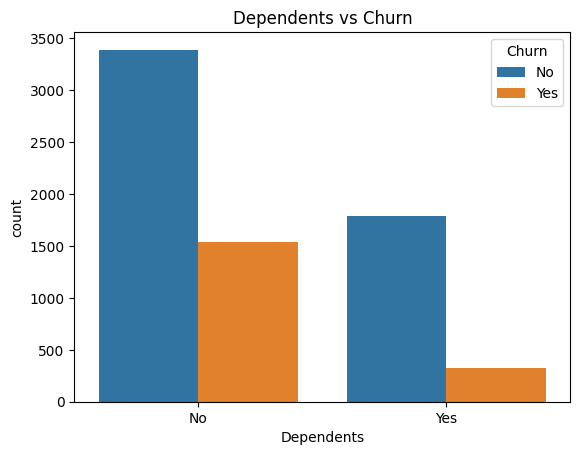

In [13]:
sns.countplot(data=df, x='Dependents', hue='Churn')
plt.title('Dependents vs Churn')
plt.show()

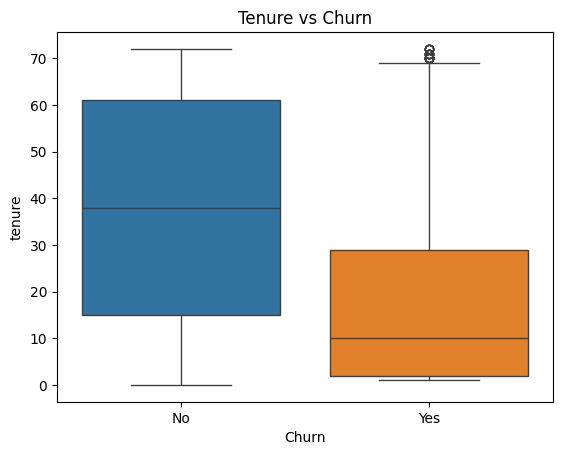

In [14]:
sns.boxplot(df, x= 'Churn', y= 'tenure', hue= 'Churn')
plt.title('Tenure vs Churn')
plt.show()

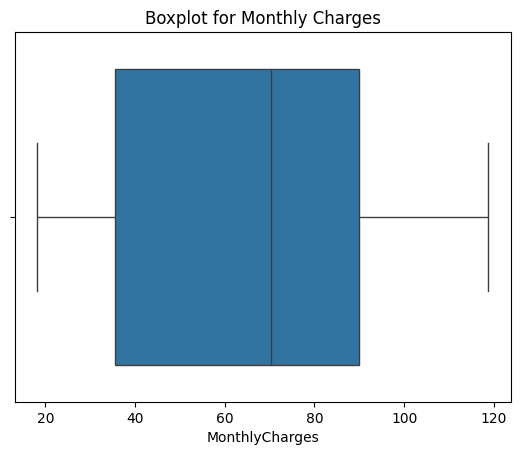

In [15]:
sns.boxplot(df, x= 'MonthlyCharges')
plt.title("Boxplot for Monthly Charges")
plt.show()

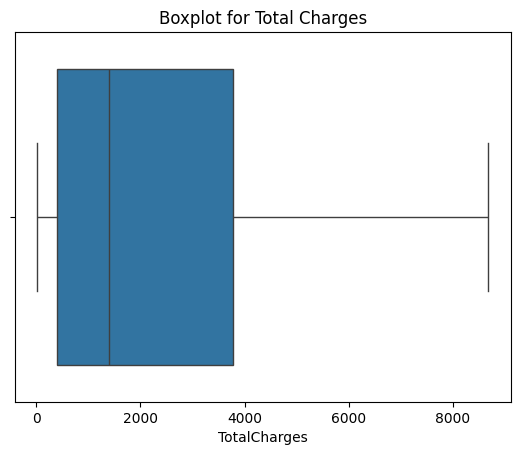

In [16]:
sns.boxplot(df, x= 'TotalCharges')
plt.title("Boxplot for Total Charges")
plt.show()

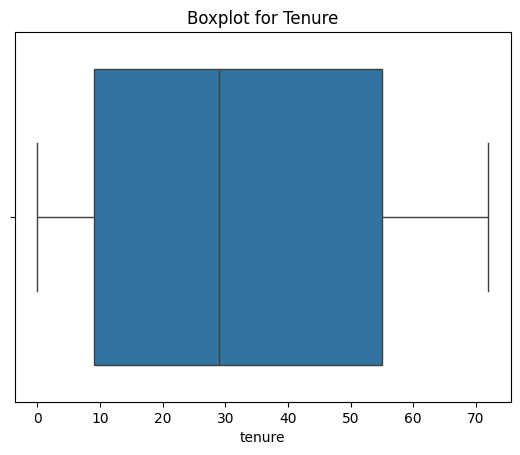

In [17]:
sns.boxplot(df, x= 'tenure')
plt.title("Boxplot for Tenure")
plt.show()

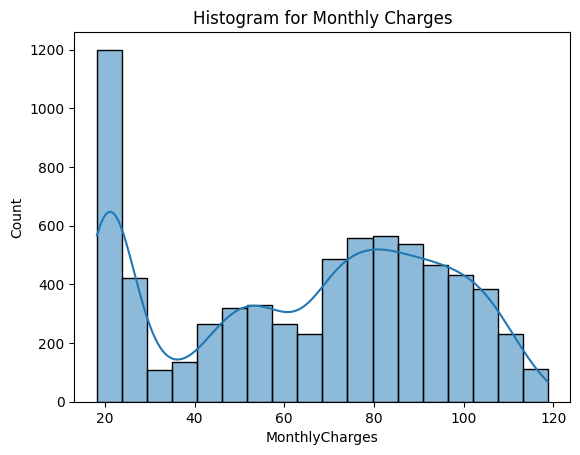

In [18]:
sns.histplot(df, x ='MonthlyCharges', kde = True)
plt.title("Histogram for Monthly Charges")
plt.show()

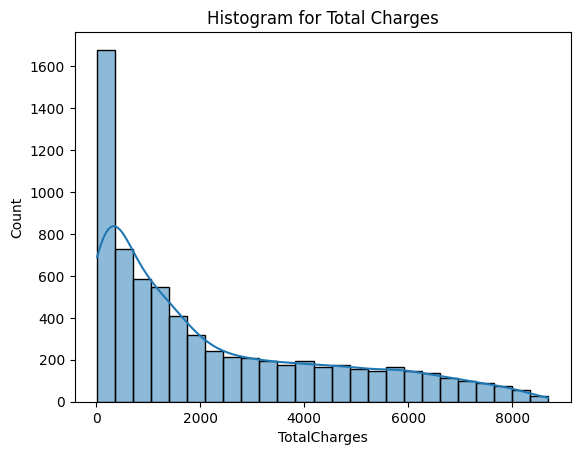

In [19]:
sns.histplot(df, x ='TotalCharges', kde= True)
plt.title("Histogram for Total Charges")
plt.show()

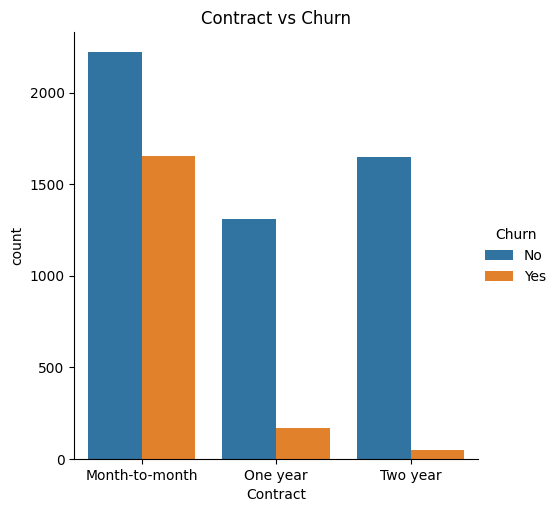

In [20]:
sns.catplot(data=df, x='Contract', hue='Churn', kind='count')
plt.title('Contract vs Churn')
plt.show()

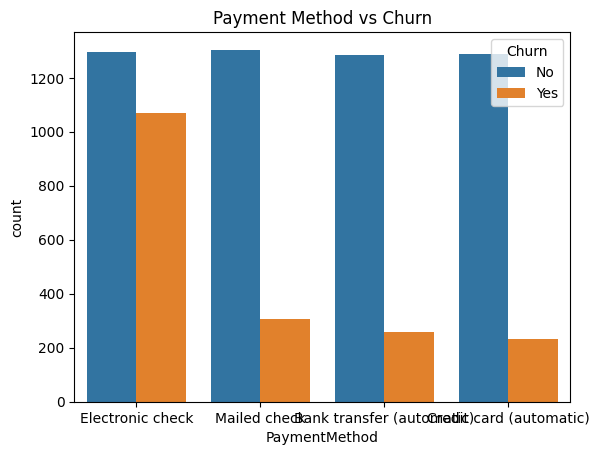

In [21]:
sns.countplot(data=df, x='PaymentMethod', hue='Churn')
plt.title('Payment Method vs Churn')
plt.show()

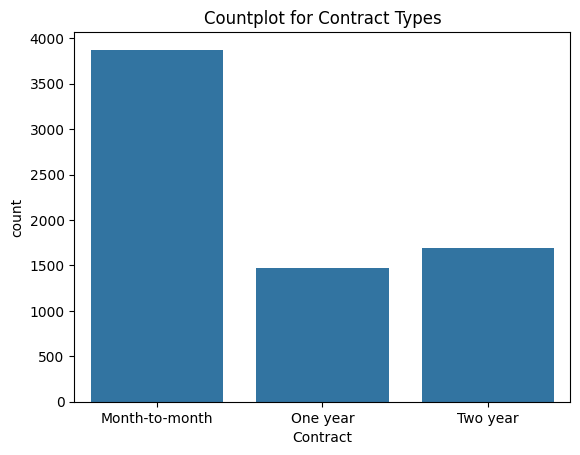

In [22]:
sns.countplot(df, x= 'Contract')
plt.title("Countplot for Contract Types")
plt.show()

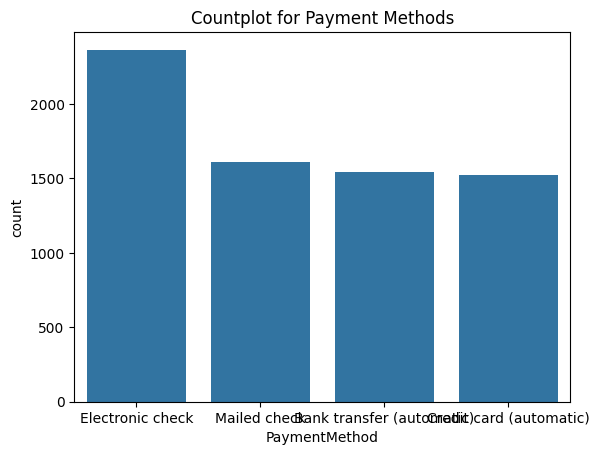

In [23]:
sns.countplot(df, x= 'PaymentMethod')
plt.title("Countplot for Payment Methods")
plt.show()

## Data Feature Engineering

In [24]:
# Drop customerID column
df = df.drop('customerID', axis= 1)

In [28]:
categorical_cols = df.select_dtypes(exclude = [np.number]).columns
categorical_cols

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

In [29]:
# Encode all categorical columns using LabelEncoder
df[categorical_cols] = df[categorical_cols].apply(lambda col: LabelEncoder().fit_transform(col))

In [30]:
df[categorical_cols]

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
0,0,1,0,0,1,0,0,2,0,0,0,0,0,1,2,0
1,1,0,0,1,0,0,2,0,2,0,0,0,1,0,3,0
2,1,0,0,1,0,0,2,2,0,0,0,0,0,1,3,1
3,1,0,0,0,1,0,2,0,2,2,0,0,1,0,0,0
4,0,0,0,1,0,1,0,0,0,0,0,0,0,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,1,1,1,2,0,2,0,2,2,2,2,1,1,3,0
7039,0,1,1,1,2,1,0,2,2,0,2,2,1,1,1,0
7040,0,1,1,0,1,0,2,0,0,0,0,0,0,1,2,0
7041,1,1,0,1,2,1,0,0,0,0,0,0,0,1,3,1


## Train-Test Split

In [31]:
# Separate features and target
X = df.drop(['Churn'],  axis= 1)
y = df['Churn']

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

## Model training and testing

In [37]:
log_reg = LogisticRegression(max_iter= 1400)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)

## Model Evaluation

In [34]:
# Compute ROC-AUC score using predicted labels
roc_score_labels = roc_auc_score(y_test, y_pred)
print("ROC-AUC Score (using predicted labels):", roc_score_labels)

# Compute ROC-AUC score using predicted probabilities
y_probs = log_reg.predict_proba(X_test)[:, 1]
roc_score_probs = roc_auc_score(y_test, y_probs)
print("ROC-AUC Score (using predicted probabilities):", roc_score_probs)

ROC-AUC Score (using predicted labels): 0.7416569192708604
ROC-AUC Score (using predicted probabilities): 0.8614994255074684


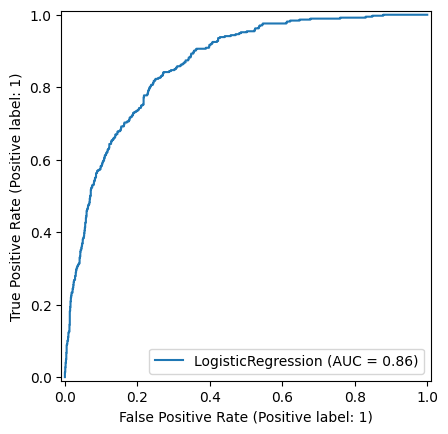

In [35]:
# Plot ROC Curve
RocCurveDisplay.from_estimator(log_reg, X_test, y_test)
plt.show()